# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La introducción todavía contiene las instrucciones entre corchetes de la plantilla. Por favor, elimina esa guía entre corchetes y sustitúyela por un breve resumen de tu proyecto (objetivo) y un esquema conciso de los pasos que planeas seguir (preparación de datos → agregación → cálculo de ingresos → EDA → pruebas de hipótesis).

</div>


<div class="alert alert-block alert-success">

# ¡Hola Bryant!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión. Corregiré algunas imprecisiones de la review de Dot y te dejaré mis propias recomendaciones o felicitaciones. 

Un gusto acompañarte en este proceso, vamos a ello!

### Comentario General Iteración #2

Quiero dejarte aqui la apreciacion general del proyecto para que sepas en lo que debes enfocarte y luego vas punto por punto revisando mis recomendaciones. 

Respecto a tu trabajo en esta primera iteración, has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets para llegar a las respuestas de negocio que se buscaban en este proyecto. Solo quedaron algunos puntos señalados donde hace falta reforzar el análisis propuesto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## Inicialización

In [ ]:
# Cargar todas las librerías
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt

## Cargar datos

In [ ]:
# Carga los archivos de datos en diferentes DataFrames
meg_calls = pd.read_csv("/datasets/megaline_calls.csv")
meg_internet = pd.read_csv("/datasets/megaline_internet.csv")
meg_messages = pd.read_csv("/datasets/megaline_messages.csv")
meg_plans = pd.read_csv("/datasets/megaline_plans.csv")
meg_users = pd.read_csv("/datasets/megaline_users.csv")


## Preparar los datos

Se creó un dataframe de cada uno de los archivos csv en el proyecto, asignando cada archivo a una variable distinta que se usará a lo largo del proyecto.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

En este paso de “exploración”, sería más claro resumir brevemente qué revisaste y qué encontraste (p. ej., columnas clave, valores faltantes, duplicados, tipos de datos y cualquier anomalía evidente) en lugar de limitarte a decir que estás explorando las tablas.

</div>


## Tarifas

In [ ]:

# Imprime la información general/resumida sobre el DataFrame de las tarifas
meg_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Imprime una muestra de los datos para las tarifas
print(meg_plans.head())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  



Megaline cuenta con 2 planes, surf y ultimate. No se encuentra ningún valor ausente en meg_plans.info(). Los tipos de datos son correctos ya que los valores enteros son unicamente las columnas de mensajes, megas, minutos y pago mensual, sin embargo, los flotantes ya aparecen cuando se excede del limite cobrando centavos por minuto. El único que debería ser tipo objeto es el nombre de plan que está en forma alfabético.
No se ve ningún problema por corregir a simple vista.


## Corregir datos

No se encontraron problemas en este DataFrame meg_plans: los tipos de datos son correctos y no hay valores ausentes. Los nombres de cada columna tiene valores adecuados así como la sintaxis snake_case adecuada.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este paso de “fix data” se deja como una celda de código vacía. Aunque no se necesiten cambios para la tabla de planes, agrega una nota breve o una pequeña validación (p. ej., confirmar nombres de columnas/dtypes) para que quede claro que el paso se completó y que no fue necesario corregir nada.

</div>


## Enriquecer los datos

No se encontraron datos por mejorar en este DataFrame meg_plans, más allá de que hay columnas que incluyen los datos en Mb mientras que otros en Gb, así solo queda en convertir los datos de las columnas a través de 1024 Mb = 1 Gb.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El paso de “enrich data” para la tabla `plans` no está realmente abordado. Considera agregar al menos una característica derivada útil para cálculos posteriores (por ejemplo, convertir los MB incluidos a GB para mejorar la legibilidad) o justificar brevemente por qué no se necesita enriquecimiento para el resto de tu análisis.

</div>


## Usuarios/as

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
meg_users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# Imprime una muestra de datos para usuarios
meg_users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


En este dataframe meg_users, encontramos errores en las columnas de fechas que están en formato object en lugar de datetime. Encontramos valores ausentes en la columna churn_date, e interpretarlos correctamente. Se puede arreglar este con las funciones pd.to_datetime(), para la columna churn_date.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Bien visto lo de que las columnas de fecha necesitan convertirse a datetime. Un par de aclaraciones: el nombre de la columna es `churn_date` (no “churn_name”), y es esperable que falten valores en `churn_date` para clientes que siguen activos—por lo que no hace falta “arreglarlos”, solo interpretarlos correctamente.

</div>


### Corregir los datos

In [ ]:
meg_users["reg_date"] = pd.to_datetime(meg_users["reg_date"])
meg_users["churn_date"] = pd.to_datetime(meg_users["churn_date"])
meg_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enriquecer los datos

Se puede añadir un indicador booleano como churn_date.notna() para señalar si un usuario hizo churn, incluso crear una nueva columna con mes de alta y/o baja.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El paso de “enrich data” para la tabla de usuarios aún no se ha intentado. Considera añadir características sencillas que puedan ayudar en análisis posteriores, como el mes/año de registro, o un indicador booleano como `churn_date.notna()` para señalar si un usuario hizo churn.

</div>


## Llamadas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
meg_calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Imprime una muestra de datos para las llamadas
meg_calls.head()


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Para el dataframe megcalls noto que la columna id viene en formato object, aunque no estoy muy seguro si debe ser entero ya que hay un guion bajo estorbando. La columna call_date está en formato object, igual debemos cambiar a pd.to_datetime(), y la columna duration debemos redondear al entero próximo más alto, ya que se muestra en la descripción que así es como se cobra en la tarifa.

### Corregir los datos

In [ ]:
meg_calls["call_date"] = pd.to_datetime(meg_calls["call_date"])
meg_calls["duration"] = np.ceil(meg_calls["duration"]).astype("int")
meg_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9
1,1000_145,1000,2018-12-27,14
2,1000_247,1000,2018-12-27,15
3,1000_309,1000,2018-12-28,6
4,1000_380,1000,2018-12-30,5


### Enriquecer los datos

Lo que podemos hacer para mejorarlo quizá sera agrupar los datos para cada user_id.

In [ ]:
meg_calls.groupby("user_id")["duration"].sum() #nos muestra cuantos minutos 
#tiene cada user_id en llamadas, es decir, cuánto usan el servicio.

user_id
1000     124
1001    1728
1002     829
1003    1104
1004    2772
        ... 
1495    1765
1496    1455
1497     300
1498    3211
1499    1535
Name: duration, Length: 481, dtype: int64

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo al alinear el preprocesamiento de llamadas con las reglas de facturación: convertir las fechas a datetime y redondear la duración de la llamada hacia arriba por cada llamada es exactamente lo que necesitas antes de la agregación mensual.

</div>


## Mensajes

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
meg_messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprime una muestra de datos para los mensajes
meg_messages.head()


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


Para el dataframe meg_messages noto que la columna message_date viene en formato object, igual debemos cambiar a pd.to_datetime().

### Corregir los datos

Corrigiendo a datetime:

In [ ]:
meg_messages["message_date"] = pd.to_datetime(meg_messages["message_date"])


### Enriquecer los datos

Podemos agrupar los datos a través de los user_id

In [ ]:
meg_messages.groupby("user_id").count()

,id,message_date
user_id,,
1000,11,11
1001,207,207
1002,88,88
1003,50,50
1004,177,177
...,...,...
1491,409,409
1492,108,108
1494,174,174


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Bien hecho: identificaste el problema clave (el tipo de dato de la fecha del mensaje), lo convertiste correctamente a datetime y exploraste el uso agregado. Esto te deja bien preparado para cálculos mensuales por usuario.

</div>


## Internet

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de internet
meg_internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Imprime una muestra de datos para el tráfico de internet
meg_internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


En el dataframe meg_internet, tenemos que cambiar el tipo de dato en la columna session_date de object a datetime. Debemos redondear la columma mb_used al entero arriba más cercano.

### Corregir los datos

Corrigiendo:

In [ ]:
meg_internet["session_date"] = pd.to_datetime(meg_internet["session_date"])
meg_internet["mb_used"] = meg_internet["mb_used"].astype("int")


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Redondear `mb_used` hacia arriba a nivel de *sesión* cambia los datos de una forma que no se ajusta a las reglas del proyecto. El uso de Internet normalmente se suma primero para el mes y solo después se redondea hacia arriba a GB completos para la facturación; el redondeo a nivel de sesión sobreestimará el uso y distorsionará los ingresos más adelante.

</div>


### Enriquecer los datos

Podemos implementar a la columna mb_used una nueva columna que muestre la cantidad de gb_used. Ya que un 1 gb = 1024 mb, y a partir de 1025 mb se cuenta como 2 gb de consumo, podemos partir que después de cada múltiplo de 1024m + 1, donde m = 1, 2, 3, ...., así redondear al gb más próximo para la tarifa, y hacerlo para que cada usuario conozca su consumo mensual

In [ ]:
#hello = meg_internet[meg_internet.groupby("user_id")]
meg_internet["month"] = meg_internet["session_date"].dt.month
new_internet = meg_internet.groupby(["user_id", "month"])["mb_used"].sum()
new_internet = new_internet.to_frame()
new_internet["gb_used"] = np.ceil(new_internet["mb_used"]/1024).astype("int")
new_internet = new_internet.drop("mb_used", axis = 1)
new_internet

gb_used
user_id month         
1000    12           2
1001    8            7
        9           13
        10          22
        11          19
...                ...
1498    12          23
1499    9           13
        10          20
        11          17
        12          22

[2277 rows x 1 columns]

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo con las correcciones iniciales y el enriquecimiento de los diferentes datasets.  

## Estudiar las condiciones de las tarifas

Imprimiendo la información de la tarifa para ver una vez más sus condiciones:

In [ ]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
meg_plans


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen paso al mostrar las condiciones del plan antes de calcular los ingresos: confirmar aquí las reglas de facturación ayuda a mantener los cálculos posteriores consistentes y más fáciles de verificar.

</div>


## Agregar datos por usuario

Agregando los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo:

In [ ]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
meg_calls["month"] = meg_calls["call_date"].dt.month
llamadas = meg_calls.groupby(["user_id", "month"]).size()
llamadas = llamadas.to_frame()
llamadas.columns = ["number_of_calls"]
print(llamadas)

               number_of_calls
user_id month                 
1000    12                  16
1001    8                   27
        9                   49
        10                  65
        11                  64
...                        ...
1498    12                  39
1499    9                   41
        10                  53
        11                  45
        12                  65

[2258 rows x 1 columns]


In [ ]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutos = meg_calls.groupby(["user_id", "month"])["duration"].sum()

minutos = pd.DataFrame(minutos)
minutos.columns = ["total_minutes"]

print(minutos)

               total_minutes
user_id month               
1000    12               124
1001    8                182
        9                315
        10               393
        11               426
...                      ...
1498    12               339
1499    9                346
        10               385
        11               308
        12               496

[2258 rows x 1 columns]


In [ ]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
meg_messages["month"] = meg_messages["message_date"].dt.month
mensajes = meg_messages.groupby(["user_id", "month"])["id"].count()
mensajes = mensajes.to_frame()

mensajes.columns = ["number_of_messages"]
print(mensajes)


               number_of_messages
user_id month                    
1000    12                     11
1001    8                      30
        9                      44
        10                     53
        11                     36
...                           ...
1496    9                      21
        10                     18
        11                     13
        12                     11
1497    12                     50

[1806 rows x 1 columns]


In [ ]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
meg_internet["month"] = meg_internet["session_date"].dt.month
trafico = np.ceil(meg_internet.groupby(["user_id", "month"])["mb_used"].sum()).astype("int")
trafico = trafico.to_frame()
trafico.columns = ["volume_mb"]
print(trafico)

               volume_mb
user_id month           
1000    12          1899
1001    8           6908
        9          13294
        10         22308
        11         18477
...                  ...
1498    12         23106
1499    9          12967
        10         19465
        11         16793
        12         22034

[2277 rows x 1 columns]


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente uso del `groupby` para los diferentes dataframes y muy buen uso de `rename` para guardar los datos calculados en una nueva columna. </div>

Juntando los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado:

In [ ]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
izq = pd.merge(llamadas, minutos, on = ["user_id", "month"], how = "outer")
der = pd.merge(mensajes, trafico, on = ["user_id", "month"], how = "outer")
union = pd.merge(izq, der, on = ["user_id", "month"], how = "outer")
union = union.reset_index()
union[["number_of_calls", "total_minutes",  "number_of_messages",  "volume_mb"]] = union[["number_of_calls", "total_minutes",  "number_of_messages",  "volume_mb"]].fillna(0)
union

,user_id,month,number_of_calls,total_minutes,number_of_messages,volume_mb
0,1000,12,16.0,124.0,11.0,1899.0
1,1001,8,27.0,182.0,30.0,6908.0
2,1001,9,49.0,315.0,44.0,13294.0
3,1001,10,65.0,393.0,53.0,22308.0
4,1001,11,64.0,426.0,36.0,18477.0
...,...,...,...,...,...,...
2288,1349,12,0.0,0.0,61.0,13027.0
2289,1361,5,0.0,0.0,2.0,1516.0
2290,1482,10,0.0,0.0,2.0,0.0
2291,1108,12,0.0,0.0,0.0,233.0


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Al construir el dataset por usuario por mes, usar merges internos (inner merges) entre llamadas/mensajes/internet elimina los meses de usuario en los que no se utilizó algún servicio (p. ej., 0 mensajes). Eso puede sesgar los promedios y los ingresos. Considera usar outer joins y rellenar los valores de uso faltantes con 0 antes de calcular los cargos mensuales.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Buen trabajo! Hiciste muy buen uso de `merge` para fusionar los diferentes datos. 
</div>

In [ ]:
# Añade la información de la tarifa
plan = pd.merge(meg_users,union, on = ["user_id"])
plan["plan_name"] = plan["plan"]

union2 = pd.merge(plan, meg_plans, on = "plan_name").drop("plan", axis = 1)
union2["net_income_messages"] = ((union2["number_of_messages"] - union2["messages_included"]).clip(lower = 0)) * union2["usd_per_message"]
union2["net_income_minutes"] = ((union2["total_minutes"] - union2["minutes_included"]).clip(lower = 0)) * union2["usd_per_minute"]
union2["net_income_gb"] = ((((union2["volume_mb"] - union2["mb_per_month_included"]).clip(lower = 0)) / 1024) * union2["usd_per_gb"])
union2["net_income_user_total_usd"] = (union2["net_income_messages"] + union2["net_income_minutes"] + union2["net_income_gb"] + union2["usd_monthly_pay"])

union2


,user_id,first_name,last_name,age,city,reg_date,churn_date,month,number_of_calls,total_minutes,...,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,net_income_messages,net_income_minutes,net_income_gb,net_income_user_total_usd
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,NaT,12,16.0,124.0,...,30720,3000,70,7,0.01,0.01,0.0,0.0,0.000000,70.000000
1,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,2018-12-18,11,2.0,10.0,...,30720,3000,70,7,0.01,0.01,0.0,0.0,0.000000,70.000000
2,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,2018-12-18,12,9.0,59.0,...,30720,3000,70,7,0.01,0.01,0.0,0.0,9.331055,79.331055
3,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,NaT,10,71.0,476.0,...,30720,3000,70,7,0.01,0.01,0.0,0.0,0.000000,70.000000
4,1008,Emely,Hoffman,53,"Orlando-Kissimmee-Sanford, FL MSA",2018-08-03,NaT,11,63.0,446.0,...,30720,3000,70,7,0.01,0.01,0.0,0.0,0.000000,70.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,NaT,12,39.0,339.0,...,15360,500,20,10,0.03,0.03,0.0,0.0,75.644531,95.644531
2289,1499,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,NaT,9,41.0,346.0,...,15360,500,20,10,0.03,0.03,0.0,0.0,0.000000,20.000000
2290,1499,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,NaT,10,53.0,385.0,...,15360,500,20,10,0.03,0.03,0.0,0.0,40.087891,60.087891
2291,1499,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,NaT,11,45.0,308.0,...,15360,500,20,10,0.03,0.03,0.0,0.0,13.994141,33.994141


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El cálculo del cargo por datos extra necesita un ajuste: la facturación requiere redondear los *MB extra mensuales* hacia arriba a GB completos y luego multiplicar por el precio por GB. Además, evita convertir valores monetarios a enteros: hacerlo elimina los centavos y puede cambiar el ingreso final (especialmente en cargos por minuto y por mensaje).

</div>


Notando todo lo que se hizo paso a paso:

Fusionamos con merge la columnas de meg_users con union para obtener el plan de cada usuario. En seguida se creó la columna plan_name y se copió la columna plan con el nombre correcto para hacer el match con meg_plans. 
Después se usó merge para fusionar con meg_plans usando plan_name. Además de que se eliminaron las columnas duplicadas con .drop("plan", axis=1).


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente trabajo con el calculo del ingreso mensual por usuario. Me gustó que al usar directamente las columnas del dataset ya estás considerando que cada plan tiene una tasa de cobro diferente y por ello tienen a su vez sobrecostos distintos. Buen uso de `clip(lower=0)`.

In [ ]:

# Calcula el ingreso mensual para cada usuario

union2[["user_id", "plan_name", "net_income_messages", "net_income_minutes", "net_income_gb", "net_income_user_total_usd"]]


,user_id,plan_name,net_income_messages,net_income_minutes,net_income_gb,net_income_user_total_usd
0,1000,ultimate,0.0,0.0,0.000000,70.000000
1,1006,ultimate,0.0,0.0,0.000000,70.000000
2,1006,ultimate,0.0,0.0,9.331055,79.331055
3,1008,ultimate,0.0,0.0,0.000000,70.000000
4,1008,ultimate,0.0,0.0,0.000000,70.000000
...,...,...,...,...,...,...
2288,1498,surf,0.0,0.0,75.644531,95.644531
2289,1499,surf,0.0,0.0,0.000000,20.000000
2290,1499,surf,0.0,0.0,40.087891,60.087891
2291,1499,surf,0.0,0.0,13.994141,33.994141


In [ ]:

# Calcula el ingreso mensual para cada usuario

union2[["user_id", "plan_name", "net_income_messages", "net_income_minutes", "net_income_gb", "net_income_user_total_usd"]]


,user_id,plan_name,net_income_messages,net_income_minutes,net_income_gb,net_income_user_total_usd
0,1000,ultimate,0.0,0.0,0.000000,70.000000
1,1006,ultimate,0.0,0.0,0.000000,70.000000
2,1006,ultimate,0.0,0.0,9.331055,79.331055
3,1008,ultimate,0.0,0.0,0.000000,70.000000
4,1008,ultimate,0.0,0.0,0.000000,70.000000
...,...,...,...,...,...,...
2288,1498,surf,0.0,0.0,75.644531,95.644531
2289,1499,surf,0.0,0.0,0.000000,20.000000
2290,1499,surf,0.0,0.0,40.087891,60.087891
2291,1499,surf,0.0,0.0,13.994141,33.994141


In [ ]:

# Calcula el ingreso mensual para cada usuario
print(f"Recordar que el usuario del plan Surf tiene un pago fijo mensual de 20 USD, mientras que el usuario del plan Ultimate tiene un pago fijo mensual de 70 USD")
print("Así pues, considerando todas las columnas plan_name, net_income_messages, net_income_minutes y net_income_gb, podemos encontrar que net_income_user_total_usd tiene valores incrementados en su valor fijo")


Recordar que el usuario del plan Surf tiene un pago fijo mensual de 20 USD, mientras que el usuario del plan Ultimate tiene un pago fijo mensual de 70 USD
Así pues, considerando todas las columnas plan_name, net_income_messages, net_income_minutes y net_income_gb, podemos encontrar que net_income_user_total_usd tiene valores incrementados en su valor fijo


In [ ]:
union2[["user_id", "plan_name", "net_income_messages", "net_income_minutes", "net_income_gb", "net_income_user_total_usd"]]


,user_id,plan_name,net_income_messages,net_income_minutes,net_income_gb,net_income_user_total_usd
0,1000,ultimate,0.0,0.0,0.000000,70.000000
1,1006,ultimate,0.0,0.0,0.000000,70.000000
2,1006,ultimate,0.0,0.0,9.331055,79.331055
3,1008,ultimate,0.0,0.0,0.000000,70.000000
4,1008,ultimate,0.0,0.0,0.000000,70.000000
...,...,...,...,...,...,...
2288,1498,surf,0.0,0.0,75.644531,95.644531
2289,1499,surf,0.0,0.0,0.000000,20.000000
2290,1499,surf,0.0,0.0,40.087891,60.087891
2291,1499,surf,0.0,0.0,13.994141,33.994141


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este paso principalmente imprime la columna de ingresos, pero el notebook sería más claro si la lógica de cálculo de ingresos mensuales se centralizara aquí (o se envolviera en una función con un nombre descriptivo) y luego se validara con algunos ejemplos de usuario-mes para confirmar que los centavos por minutos/SMS y el redondeo de GB se aplican según lo previsto.

</div>


## Estudia el comportamiento de usuario

Calculando algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión.

### Llamadas

<AxesSubplot:xlabel='month'>

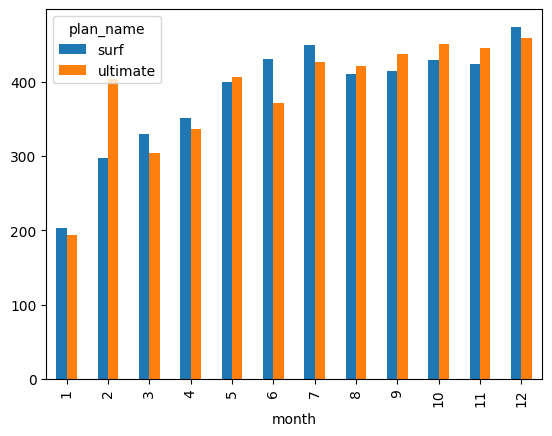

In [ ]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
union3 = union.reset_index()
uni = union2

plan_calls = uni.groupby(['plan_name', 'month'])['total_minutes'].mean()
plan_calls = pd.DataFrame(plan_calls)
plan_calls.columns = ["avg_minutes"]

plan_calls.reset_index(inplace=True)
plan_calls.pivot(index='month', columns='plan_name', values='avg_minutes').plot(kind='bar')


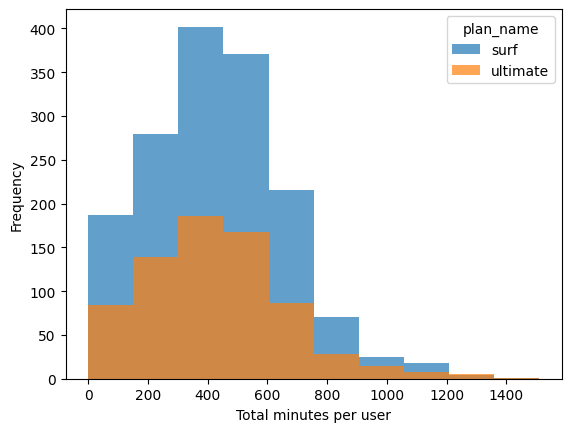

In [ ]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
plan_calls2 = uni.groupby(["plan_name", 'user_id', 'month'])["total_minutes"].sum()
plan_calls2 = pd.DataFrame(plan_calls2)
plan_calls2.reset_index(inplace = True)
plan_calls2.pivot(columns = "plan_name", values = "total_minutes").plot(kind = "hist", alpha = 0.7)
plt.xlabel("Total minutes per user")
plt.show()


Calculando la media y la varianza de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas:

In [ ]:
# Calcula la media y la varianza de la duración mensual de llamadas.
surf = uni[uni["plan_name"] == "surf"]
ultimate = uni[uni["plan_name"] == "ultimate"]

media_surf = (np.mean(surf["total_minutes"]))
var_surf = (np.var(surf["total_minutes"], ddof=1))

media_ult = (np.mean(ultimate["total_minutes"]))
var_ult = (np.var(ultimate["total_minutes"], ddof=1))

print(f"La media del tiempo en llamadas del plan surf es: {media_surf} mientras que su varianza es {var_surf}")
print(f"La media del tiempo en llamadas del plan ultimate es: {media_ult} mientras que su varianza es {var_ult}")


La media del tiempo en llamadas del plan surf es: 428.7495232040687 mientras que su varianza es 54968.27946065038
La media del tiempo en llamadas del plan ultimate es: 430.45 mientras que su varianza es 57844.46481223922


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la varianza, usa la varianza muestral (ddof=1, como pandas `.var()`), no la varianza poblacional (valor por defecto de `np.var`). Además, evita aplicar `ceil` a la media/varianza antes de reportarlas: redondear en esta etapa distorsiona las estadísticas descriptivas.

</div>


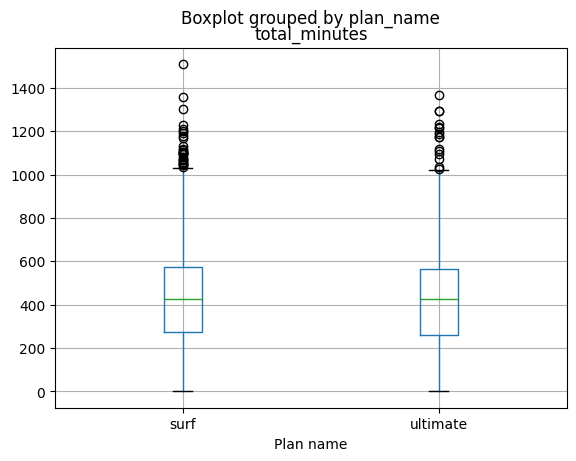

In [ ]:

# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plan_calls2.boxplot(column = "total_minutes", by = "plan_name")
plt.xlabel("Plan name")
plt.show()


En los diagramas de caja (IQR): representa el 50% central de los datos. Una caja más angosta puede implicar datos más concentrados alrededor de la mediana, así pues, el plan ultimate tiene una caja más angosta, mientras que los del plan surf utilizan sus minutos de más, pagando los extras.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La interpretación de los boxplots necesita ajustarse: una caja más estrecha no implica que los usuarios estén pagando por minutos extra. Sería más sólido comparar el uso con el límite de minutos incluidos de cada plan (p. ej., la proporción que excede el límite) y luego describir las diferencias en centro/dispersión/outliers por plan.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Genial. Tus histogramas muestran claramente la diferencia temporal de comportamiento de cada uno de los planes respecto a la duración de las llamadas y la tendencia de minutos usados al mes por plan. Excelente análisis frente a la media y las desviaciones de la duracion de las llamadas por cada plan, como mencionas, esta diferencia no es muy significativa y esto es un dato valioso. 


### Mensajes

In [ ]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
media_men = uni.groupby(['plan_name', 'month'])["number_of_messages"].mean()
media_men = pd.DataFrame(media_men)
media_men

number_of_messages
plan_name month                    
surf      1               10.500000
          2               12.000000
          3               15.260870
          4               17.400000
          5               24.012987
          6               25.298969
          7               27.033058
          8               28.777778
          9               30.762887
          10              33.839662
          11              32.385159
          12              38.600629
ultimate  1               15.500000
          2               21.571429
          3               20.250000
          4               22.047619
          5               32.103448
          6               29.340426
          7               32.830508
          8               38.478873
          9               37.895349
          10              39.443396
          11              38.606299
          12              45.006623

In [ ]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
media_men = uni.groupby(['plan_name', 'month'])["number_of_messages"].mean()
media_men = pd.DataFrame(media_men)
media_men

number_of_messages
plan_name month                    
surf      1               10.500000
          2               12.000000
          3               15.260870
          4               17.400000
          5               24.012987
          6               25.298969
          7               27.033058
          8               28.777778
          9               30.762887
          10              33.839662
          11              32.385159
          12              38.600629
ultimate  1               15.500000
          2               21.571429
          3               20.250000
          4               22.047619
          5               32.103448
          6               29.340426
          7               32.830508
          8               38.478873
          9               37.895349
          10              39.443396
          11              38.606299
          12              45.006623

In [ ]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
media_men = uni.groupby(['plan_name', 'month'])["number_of_messages"].mean()
media_men = pd.DataFrame(media_men)
media_men = media_men.reset_index()
media_men

,plan_name,month,number_of_messages
0,surf,1,10.500000
1,surf,2,12.000000
2,surf,3,15.260870
3,surf,4,17.400000
4,surf,5,24.012987
5,surf,6,25.298969
6,surf,7,27.033058
7,surf,8,28.777778
8,surf,9,30.762887
9,surf,10,33.839662


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para los mensajes mensuales, actualmente calculas solo medias generales. Para alinearte con la tarea (“por plan y por mes”), considera agrupar por `['plan_name','month']` y añadir al menos un gráfico de distribución (histogram/boxplot) además de estadísticas descriptivas (mean/variance/std) por plan (opcionalmente por mes).

</div>


In [ ]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
media_mb_surf = np.ceil(surf["volume_mb"].mean())
media_mb_ultimate = np.ceil(ultimate["volume_mb"].mean())
print(f"Los usuarios de surf suelen usar en promedio {media_mb_surf} mb al mes. Mientras que los de ultimate suelen usar en promedio {media_mb_ultimate} mb al mes.")



Los usuarios de surf suelen usar en promedio 16539.0 mb al mes. Mientras que los de ultimate suelen usar en promedio 17195.0 mb al mes.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta celda está colocada bajo la sección Messages, pero analiza el uso de internet. Mueve este análisis a la subsección Internet y mantén esta sección enfocada en comparar los mensajes por plan (incluyendo gráficos y estadísticos descriptivos).

</div>


<AxesSubplot:title={'center':'number_of_messages'}, xlabel='plan_name'>

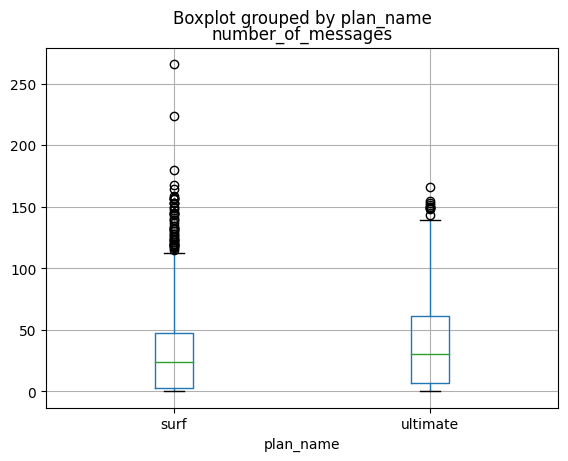

In [ ]:
uni.boxplot(by = "plan_name", column = "number_of_messages")

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este bloque de Messages tiene una celda de código vacía, lo que deja incompleto el análisis requerido de mensajes. Agrega las visualizaciones/estadísticas faltantes de mensajes mensuales por plan antes de redactar conclusiones.

</div>


El plan Ultimate incluye más mensajes gratuitos que Surf. Y la media de mensajes de Ultimate es 47 y la de Surf es 40, así que los usuarios de Ultimate están aprovechando su plan. 

Las medias de datos mb son 16,649 MB (Surf) y 17,271 MB (Ultimate), y si los MB que incluye cada plan sin costo extra es 15 GB (15360 mb)  y 30 GB (30720 mb), respectivamente. Así que surf tiene más probabilidad de que sus usuarios paguen excedentes.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente trabajo aqui con la seccion de Mensajes, todos los graficos y medidas estadisticas solicitadas se encuentran completos. Genial los puntos que señalas sobre las tendencias generales y los valores atípicos en ambos planes. 

### Internet

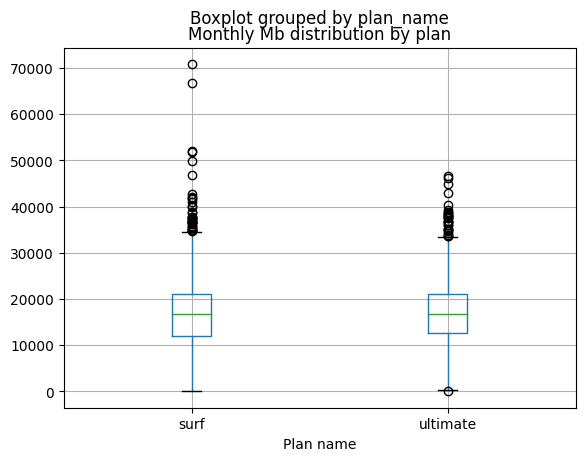

In [ ]:
plan_calls3 = uni.groupby(['plan_name', 'user_id', 'month'])["volume_mb"].sum()
plan_calls3 = pd.DataFrame(plan_calls3)
plan_calls3.reset_index(inplace = True)

plan_calls3.boxplot(column = "volume_mb", by = "plan_name")
plt.title("Monthly Mb distribution by plan")
plt.xlabel("Plan name")
plt.show()


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta subsección está etiquetada como Internet, pero el código todavía está agregando/graficando mensajes (`number_of_messages_x`). Sustituye esto por un análisis del uso mensual de internet por plan para cumplir con los requisitos de la tarea de Internet.

</div>


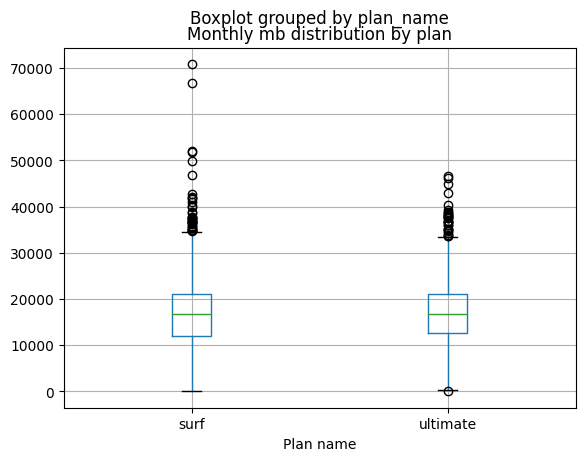

In [ ]:
plan_calls4 = uni.groupby(["plan_name", 'user_id', 'month'])["volume_mb"].sum()
plan_calls4 = pd.DataFrame(plan_calls4)
plan_calls4.reset_index(inplace = True)

plan_calls4.boxplot(column = "volume_mb", by = "plan_name")
plt.title("Monthly mb distribution by plan")
plt.xlabel("Plan name")
plt.show()

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Por favor, verifica que estás graficando la variable correcta de uso mensual de internet. Después de los merges, columnas como `volume_mb_x`/`volume_mb_y` pueden resultar confusas; asegúrate de que la gráfica use el total mensual de internet previsto (y que el redondeo relacionado con la facturación se aplique en la etapa correcta).

</div>


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

A este bloque de análisis de Internet le falta un paso adicional obligatorio (la celda de código está vacía). Añade un análisis complementario, como mean/variance/std por plan y/o un histograma/boxplot del uso mensual de Internet.

</div>


Sobre los mensajes:
Los usuarios de Ultimate tienen un límite de 1,000 mensajes incluidos, pero su media es solo 47, mientras que Surf son 50 mensajes y media de 40. Nos quiere decir que en realidad los usuarios Ultimate no están acostumbrados a enviar mensajes, a pesar que lo pagan.

Acerca de los mb:
Surf: media de ~16,649 MB vs límite de 15,360 MB → superan el límite
Ultimate: media de ~17,271 MB vs límite de 30,720 MB → muy por debajo del límite

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelente análisis frente al consumo de internet por plan. De nuevo como remarcas, el comportamiento entre ambos planes es similar, siendo uno de los mayores diferenciadores el consumo de excedentes por parte de los usuarios del plan surf. 
</div>

## Ingreso

Describiendo estadísticamente los ingresos de los planes

In [ ]:
net_income_user_surf = np.ceil(uni[uni["plan_name"] == "surf"]["net_income_user_total_usd"].mean())
net_income_user_ultimate = np.ceil(uni[uni["plan_name"] == "ultimate"]["net_income_user_total_usd"].mean())

print(f"Los usuarios de surf suelen gastar en promedio {net_income_user_surf} USD al mes. Mientras que los de ultimate suelen usar en promedio {net_income_user_ultimate} USD al mes.")


Los usuarios de surf suelen gastar en promedio 58.0 USD al mes. Mientras que los de ultimate suelen usar en promedio 73.0 USD al mes.


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la descripción de revenue, incluye algo más que la media. Añade medidas de variabilidad (varianza y desviación estándar, o una tabla resumen descriptiva) por plan, e interpreta cómo se ve la distribución (dispersión/outliers) además del promedio.

</div>


<AxesSubplot:title={'center':'net_income_user_total_usd'}, xlabel='plan_name'>

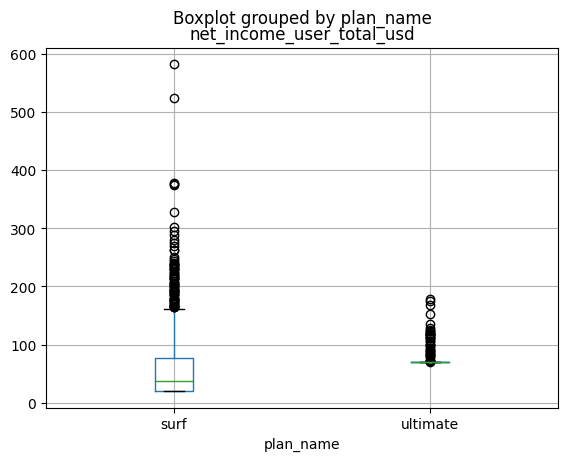

In [ ]:
usd_plan = uni.groupby(["plan_name", "user_id", "month"])["net_income_user_total_usd"].mean()
usd_plan = pd.DataFrame(usd_plan)
usd_plan.boxplot(column = "net_income_user_total_usd", by = "plan_name")

<AxesSubplot:xlabel='month'>

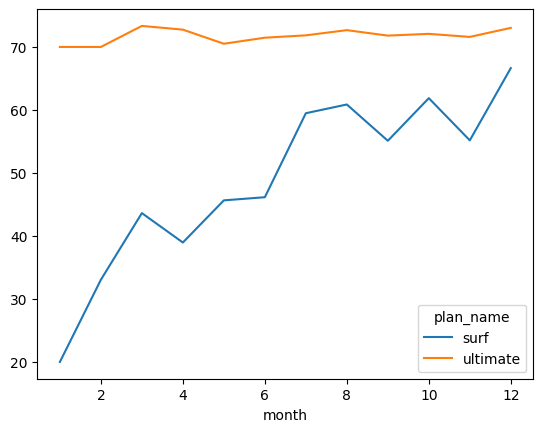

In [ ]:
net_usd = uni.groupby(['plan_name', 'month'])["net_income_user_total_usd"].mean()
net_usd = net_usd.reset_index()
net_usd = pd.DataFrame(net_usd)
net_usd.pivot(columns= "plan_name", index= "month", values= "net_income_user_total_usd").plot()


Los usuarios de surf suelen gastar en promedio 57.0 USD al mes. Mientras que los de ultimate suelen usar en promedio 73.0 USD al mes.

Mientras más nos acercamos a fin de año, la cantidad de ingresos por usuario, aumenta significamente para surf, mientras que para ultimate se mantiene estable en el tiempo. Las fechas navideñas definitivamente pueden influir en el comportamiento de los usuarios.


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tus conclusiones sobre los ingresos se centran en promedios y en una tendencia temporal, pero no interpretan la variabilidad. Por favor, compara brevemente las distribuciones de ingresos entre los planes (dispersión, valores atípicos) basándote en tus gráficos y conéctalo con lo que eso implica sobre cómo Surf vs Ultimate generan ingresos.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Genial! Frente a la clara estabilidad del plan ultimate frente al surf, las recomendaciones que das en temas de retención y potencial son excelentes.

## Prueba las hipótesis estadísticas

Probando la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf, es decir, que son bilateral: μ_surf ≠ μ_ultimate.

Hipótesis nula = No hay cambios en ingresos promedio de planes distintos
Hipótesis alternativa = Si hay cambios en ingresos promedio de planes distintos.

μ → H₀: μ_surf = μ_ultimate
Aclarar que es bilateral → H₁: μ_surf ≠ μ_ultimate

alfa = 0.05

Muestras independientes → Los usuarios de Surf y Ultimate son grupos distintos, no los mismos usuarios. Comparación de medias → Se compara μ_surf vs μ_ultimate. Alfa = 0.05 → Nivel de significancia estándar.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Por favor, formula las hipótesis con mayor precisión en términos del ingreso mensual promedio de la población (por ejemplo, μ_surf y μ_ultimate) y aclara si se trata de una prueba bilateral (μ_surf ≠ μ_ultimate). Además, añade una breve justificación para usar una prueba t de dos muestras (muestras independientes, comparación de medias).

</div>


In [ ]:
# Prueba las hipótesis
alpha = 0.05
surf = uni[uni["plan_name"] == "surf"]["net_income_user_total_usd"]
ultimate = uni[uni["plan_name"] == "ultimate"]["net_income_user_total_usd"]

prueba = st.ttest_ind(surf, ultimate, equal_var = False)

if (prueba.pvalue < alpha):# su código: compara los valores p obtenidos con el nivel de significación estadística):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Rechazamos la hipótesis nula


Si hay cambios en ingresos promedio de planes distintos. Entonces el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Esta parte debe centrarse en la comparación NY-NJ vs no NY-NJ: define claramente qué observaciones pertenecen al grupo NY-NJ (según el formato ciudad/estado del dataset) y plantea las hipótesis específicamente como una comparación de la media de ingresos mensuales entre esos dos grupos.

</div>



Hipótesis nula = No hay cambios en ingresos promedio de zonas distintas a la metropolitana de NY

Hipótesis alternativa = Si hay cambios en ingresos promedio de  zonas distintas a la metropolitana de NY

alfa = 0.05

In [ ]:
# Prueba las hipótesis
nynj = uni[uni["city"].str.contains(" NY-NJ-PA MSA")]["net_income_user_total_usd"]
notnynj = uni[~uni["city"].str.contains(" NY-NJ-PA MSA")]["net_income_user_total_usd"] 

alpha = 0.05
prueba = st.ttest_ind(nynj, notnynj, equal_var = False)

if (prueba.pvalue < alpha):# su código: compara los valores p obtenidos con el nivel de significación estadística):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Rechazamos la hipótesis nula


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

El filtro NY-NJ usando `str.contains("NY|New York|New Jersey|NJ")` es demasiado amplio y puede clasificar ubicaciones incorrectamente. Considera extraer la abreviatura del estado del campo `city` y seleccionar explícitamente solo NY y NJ, para que tus dos muestras queden correctamente definidas antes de ejecutar la prueba t.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Muy buen trabajo corriengo la extraccion de la información por ciudad como te indicó Dot. Ambas pruebas son correctas. 

## Conclusión general

Se tuvieron que hacer ajustes para varios datos en el análisis, esto es, duraciones de llamadas con decimales (con redondeos np.ceil()). Los meses fueron agrupados así como los user_id y los planes para encontrar ingresos de manera más ordenada.
Además se encontró la suma total de los ingresos netos por usuario a partir de los datos originales.

Sobre los planes:
Sobre los MB:
Los del plan Ultimate no aprovechan su plan, mientras que los del plan surf en promedio tienen que pagar el excedente.
Surf: media ~16,649 MB vs límite 15,360 MB → superan el límite
Ultimate: media ~17,271 MB vs límite 30,720 MB → muy por debajo del límite

Sobre NY-NJ:
La diferencia de ingresos entre NY-NJ y otras regiones fue estadísticamente significativa. Con un p-value de 0.019421224481805353 y un nivel de significancia de 0.05, rechazamos la hipótesis nula. Esto significa que sí hay una diferencia estadísticamente significativa entre los ingresos de NY-NJ y el resto.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tu conclusión final contradice el resultado de tu prueba de hipótesis NY-NJ: en la prueba informas que no puedes rechazar la hipótesis nula, pero aquí afirmas que la diferencia es estadísticamente significativa. Por favor, revisa para que la conclusión coincida con la decisión basada en el p-value y explica en lenguaje sencillo qué significa esa decisión.

</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #2</b> <a class="tocSkip"></a>

Excelentes conclusiones finales. Describiste detalladamente los resultados segun las categorias de llamadas, mensajes e internet para cada tipo de plan y sus hallazgos relevantes. 